In [ ]:
# Imports
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate, learning_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42


In [ ]:
# Load Dataset
# Update this path to wherever you have saved the downloaded CSV file
DATA_PATH = "/content/sample_data/train_loan.csv"
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()


Shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [11]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [12]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Loan_ID,614,614,LP002990,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,601,2,Male,489,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Married,611,2,Yes,398,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,599,4,0,345,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education,614,2,Graduate,480,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Self_Employed,582,2,No,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ApplicantIncome,614.0,NaN,NaN,NaN,5403.459283,6109.041673,150.0,2877.5,3812.5,5795.0,81000.0
CoapplicantIncome,614.0,NaN,NaN,NaN,1621.245798,2926.248369,0.0,0.0,1188.5,2297.25,41667.0
LoanAmount,592.0,NaN,NaN,NaN,146.412162,85.587325,9.0,100.0,128.0,168.0,700.0
Loan_Amount_Term,600.0,NaN,NaN,NaN,342.0,65.12041,12.0,360.0,360.0,360.0,480.0


In [13]:
# Missing value summary
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
missing


Columns with missing values:


,0
Credit_History,50
Self_Employed,32
LoanAmount,22
Dependents,15
Loan_Amount_Term,14
Gender,13
Married,3


In [ ]:
#feature/target Split
TARGET = "LoanAmount"

# Drop identifier and any classification-only column, drop rows with missing target
drop_cols = [c for c in ["Loan_ID", "Loan_Status"] if c in df.columns]
data = df.drop(columns=drop_cols).dropna(subset=[TARGET]).reset_index(drop=True)

X = data.drop(columns=[TARGET])
y = data[TARGET]

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Numerical features:", numerical_cols)
print("Categorical features:", categorical_cols)


Numerical features: ['ApplicantIncome', 'CoapplicantIncome', 'Loan_Amount_Term', 'Credit_History']
Categorical features: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']


In [15]:
# ================== Preprocessing Pipeline ==================
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numerical_cols),
    ("cat", categorical_transformer, categorical_cols),
])


In [ ]:
# Train / Test Split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (473, 10)  Test shape: (119, 10)


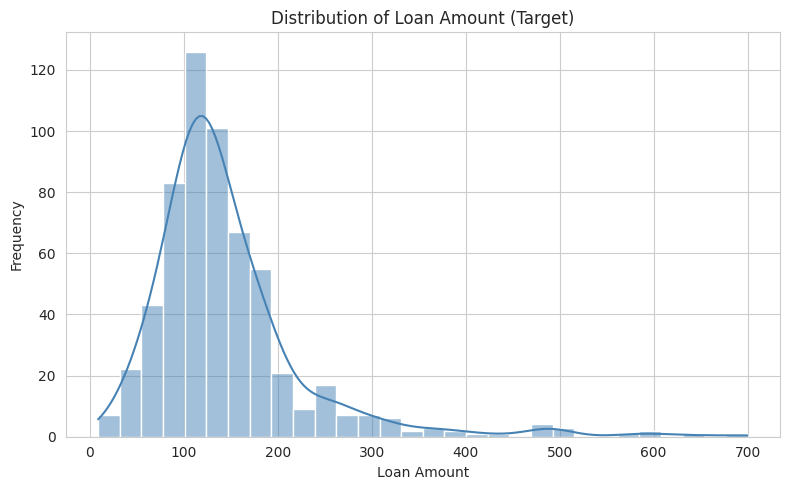

In [ ]:
# Target variable distribution
plt.figure()
sns.histplot(y, kde=True, bins=30, color="steelblue")
plt.title("Distribution of Loan Amount (Target)")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


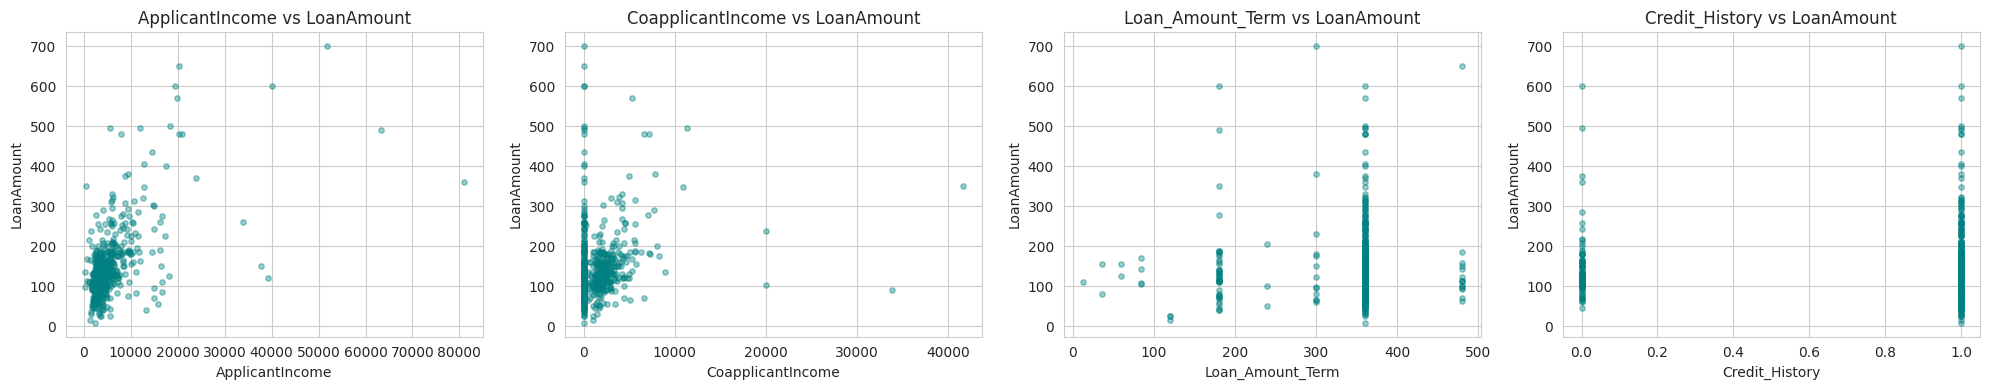

In [18]:
# ---- Feature vs target scatter plots (numerical features) ----
n = len(numerical_cols)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
if n == 1:
    axes = [axes]
for ax, col in zip(axes, numerical_cols):
    ax.scatter(X[col], y, alpha=0.4, s=15, color="teal")
    ax.set_xlabel(col)
    ax.set_ylabel(TARGET)
    ax.set_title(f"{col} vs {TARGET}")
plt.tight_layout()
plt.show()


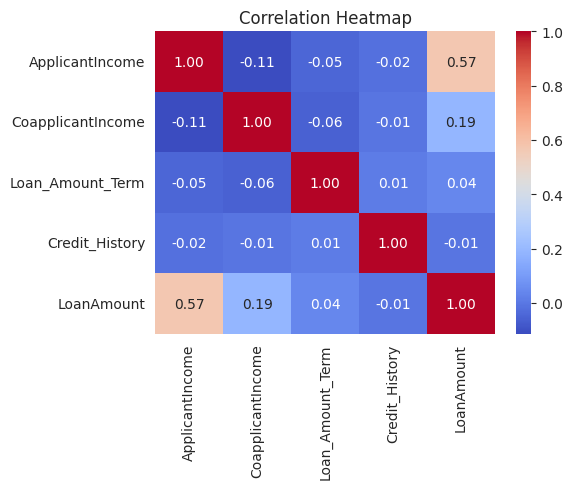

In [ ]:
#Correlation heatmap (numerical features + target)
plt.figure(figsize=(6, 5))
corr = data[numerical_cols + [TARGET]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


In [20]:
def make_pipeline(regressor):
    return Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("regressor", regressor),
    ])

def evaluate(model, X_tr, y_tr, X_te, y_te):
    """Fit (if not already fit) and return train/test metrics + timing."""
    start = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - start

    y_train_pred = model.predict(X_tr)
    y_test_pred = model.predict(X_te)

    metrics = {
        "Train_MAE": mean_absolute_error(y_tr, y_train_pred),
        "Train_MSE": mean_squared_error(y_tr, y_train_pred),
        "Train_RMSE": np.sqrt(mean_squared_error(y_tr, y_train_pred)),
        "Train_R2": r2_score(y_tr, y_train_pred),
        "MAE": mean_absolute_error(y_te, y_test_pred),
        "MSE": mean_squared_error(y_te, y_test_pred),
        "RMSE": np.sqrt(mean_squared_error(y_te, y_test_pred)),
        "R2": r2_score(y_te, y_test_pred),
        "Training_Time_s": train_time,
    }
    return model, metrics, y_test_pred


In [ ]:
#Baseline Linear Regression
lin_pipeline = make_pipeline(LinearRegression())
lin_model, lin_metrics, lin_pred = evaluate(lin_pipeline, X_train, y_train, X_test, y_test)
lin_metrics


{'Train_MAE': 41.442217900005325,
 'Train_MSE': 4453.114082865748,
 'Train_RMSE': np.float64(66.73165727648122),
 'Train_R2': 0.4557894531864223,
 'MAE': 36.60797031935969,
 'MSE': 3353.1726295800718,
 'RMSE': np.float64(57.90658537316867),
 'R2': 0.09038864935872426,
 'Training_Time_s': 0.06789898872375488}

In [ ]:
# Ridge Regression (Grid Search)
ridge_param_grid = {"regressor__alpha": [0.01, 0.1, 1, 10, 100]}

ridge_grid = GridSearchCV(
    make_pipeline(Ridge(random_state=RANDOM_STATE)),
    param_grid=ridge_param_grid,
    cv=5, scoring="r2", n_jobs=-1,
)
start = time.time()
ridge_grid.fit(X_train, y_train)
ridge_tune_time = time.time() - start

ridge_model = ridge_grid.best_estimator_
_, ridge_metrics, ridge_pred = evaluate(ridge_model, X_train, y_train, X_test, y_test)

print("Best Ridge params:", ridge_grid.best_params_)
print("Best CV R2:", ridge_grid.best_score_)
ridge_metrics


Best Ridge params: {'regressor__alpha': 100}
Best CV R2: 0.2807748543900448


{'Train_MAE': 42.58402560376063,
 'Train_MSE': 4593.189690030271,
 'Train_RMSE': np.float64(67.77307496366289),
 'Train_R2': 0.43867095557964386,
 'MAE': 36.64150037086195,
 'MSE': 3104.8517519027823,
 'RMSE': np.float64(55.72119661226581),
 'R2': 0.15775037328069053,
 'Training_Time_s': 0.016513347625732422}

In [ ]:
# Lasso Regression (Grid Search)
lasso_param_grid = {"regressor__alpha": [0.001, 0.01, 0.1, 1, 10]}

lasso_grid = GridSearchCV(
    make_pipeline(Lasso(random_state=RANDOM_STATE, max_iter=10000)),
    param_grid=lasso_param_grid,
    cv=5, scoring="r2", n_jobs=-1,
)
start = time.time()
lasso_grid.fit(X_train, y_train)
lasso_tune_time = time.time() - start

lasso_model = lasso_grid.best_estimator_
_, lasso_metrics, lasso_pred = evaluate(lasso_model, X_train, y_train, X_test, y_test)

print("Best Lasso params:", lasso_grid.best_params_)
print("Best CV R2:", lasso_grid.best_score_)
lasso_metrics


Best Lasso params: {'regressor__alpha': 10}
Best CV R2: 0.22094197109941255


{'Train_MAE': 45.88754705956615,
 'Train_MSE': 4995.223122370864,
 'Train_RMSE': np.float64(70.67689242157485),
 'Train_R2': 0.3895388583595758,
 'MAE': 37.79708423154161,
 'MSE': 3181.254854134254,
 'RMSE': np.float64(56.40261389451959),
 'R2': 0.13702459006246837,
 'Training_Time_s': 0.013950347900390625}

In [ ]:
# Elastic Net (Grid Search) 
enet_param_grid = {
    "regressor__alpha": [0.01, 0.1, 1, 10],
    "regressor__l1_ratio": [0.2, 0.5, 0.8],
}

enet_grid = GridSearchCV(
    make_pipeline(ElasticNet(random_state=RANDOM_STATE, max_iter=10000)),
    param_grid=enet_param_grid,
    cv=5, scoring="r2", n_jobs=-1,
)
start = time.time()
enet_grid.fit(X_train, y_train)
enet_tune_time = time.time() - start

enet_model = enet_grid.best_estimator_
_, enet_metrics, enet_pred = evaluate(enet_model, X_train, y_train, X_test, y_test)

print("Best Elastic Net params:", enet_grid.best_params_)
print("Best CV R2:", enet_grid.best_score_)
enet_metrics


Best Elastic Net params: {'regressor__alpha': 1, 'regressor__l1_ratio': 0.5}
Best CV R2: 0.2906081986664775


{'Train_MAE': 45.126186285748766,
 'Train_MSE': 4970.252760115791,
 'Train_RMSE': np.float64(70.50001957528657),
 'Train_R2': 0.39259046095589234,
 'MAE': 37.82989509776145,
 'MSE': 3053.432790378989,
 'RMSE': np.float64(55.257875369751495),
 'R2': 0.17169873687749304,
 'Training_Time_s': 0.0187838077545166}

In [25]:
tuning_summary = pd.DataFrame([
    {"Model": "Ridge Regression", "Search Method": "Grid Search",
     "Best Parameters": ridge_grid.best_params_, "Best CV R2": ridge_grid.best_score_},
    {"Model": "Lasso Regression", "Search Method": "Grid Search",
     "Best Parameters": lasso_grid.best_params_, "Best CV R2": lasso_grid.best_score_},
    {"Model": "Elastic Net Regression", "Search Method": "Grid Search",
     "Best Parameters": enet_grid.best_params_, "Best CV R2": enet_grid.best_score_},
])
tuning_summary


,Model,Search Method,Best Parameters,Best CV R2
0,Ridge Regression,Grid Search,{'regressor__alpha': 100},0.280775
1,Lasso Regression,Grid Search,{'regressor__alpha': 10},0.220942
2,Elastic Net Regression,Grid Search,"{'regressor__alpha': 1, 'regressor__l1_ratio':...",0.290608


In [26]:
def cv_metrics_row(name, estimator, X_tr, y_tr, cv=5):
    scoring = {
        "MAE": "neg_mean_absolute_error",
        "MSE": "neg_mean_squared_error",
        "R2": "r2",
    }
    scores = cross_validate(estimator, X_tr, y_tr, cv=cv, scoring=scoring, n_jobs=-1)
    mae = -scores["test_MAE"].mean()
    mse = -scores["test_MSE"].mean()
    return {
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R2": scores["test_R2"].mean(),
    }

cv_table = pd.DataFrame([
    cv_metrics_row("Linear Regression", make_pipeline(LinearRegression()), X_train, y_train),
    cv_metrics_row("Ridge Regression", ridge_model, X_train, y_train),
    cv_metrics_row("Lasso Regression", lasso_model, X_train, y_train),
    cv_metrics_row("Elastic Net Regression", enet_model, X_train, y_train),
])
cv_table


,Model,MAE,MSE,RMSE,R2
0,Linear Regression,45.977399,6908.725192,83.118742,0.186303
1,Ridge Regression,46.104438,5950.655681,77.140493,0.280775
2,Lasso Regression,48.638924,6480.743484,80.503065,0.220942
3,Elastic Net Regression,47.337644,5792.793881,76.110406,0.290608


In [27]:
test_table = pd.DataFrame([
    {"Model": "Linear Regression", **{k: v for k, v in lin_metrics.items() if not k.startswith("Train")}},
    {"Model": "Ridge Regression", **{k: v for k, v in ridge_metrics.items() if not k.startswith("Train")}},
    {"Model": "Lasso Regression", **{k: v for k, v in lasso_metrics.items() if not k.startswith("Train")}},
    {"Model": "Elastic Net Regression", **{k: v for k, v in enet_metrics.items() if not k.startswith("Train")}},
])
test_table


,Model,MAE,MSE,RMSE,R2
0,Linear Regression,36.607970,3353.172630,57.906585,0.090389
1,Ridge Regression,36.641500,3104.851752,55.721197,0.157750
2,Lasso Regression,37.797084,3181.254854,56.402614,0.137025
3,Elastic Net Regression,37.829895,3053.432790,55.257875,0.171699


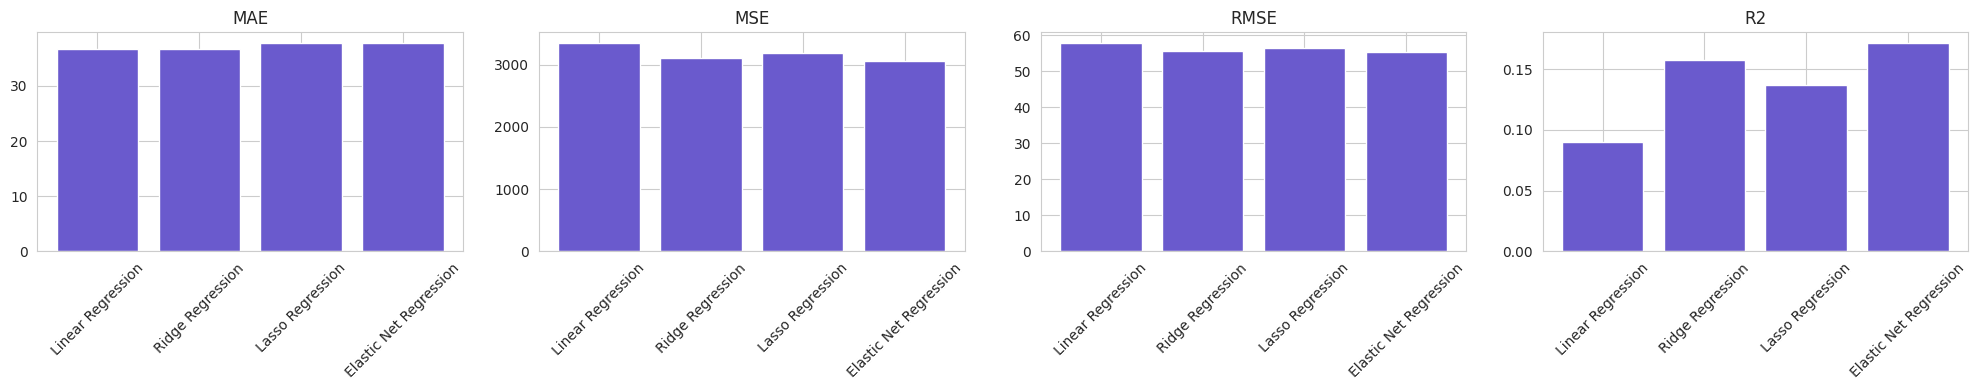

In [28]:
metrics_to_plot = ["MAE", "MSE", "RMSE", "R2"]
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, metric in zip(axes, metrics_to_plot):
    ax.bar(test_table["Model"], test_table[metric], color="slateblue")
    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


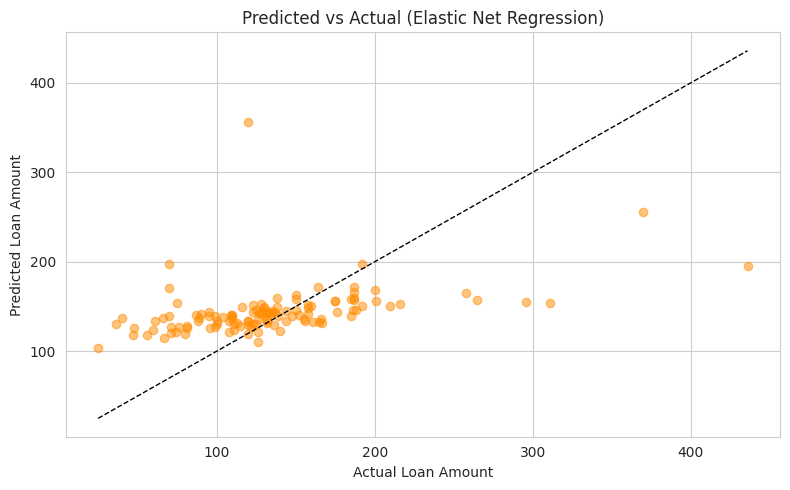

In [ ]:
# Predicted vs Actual (best model by test R2)
best_row = test_table.loc[test_table["R2"].idxmax()]
best_name = best_row["Model"]
best_pred_map = {
    "Linear Regression": lin_pred,
    "Ridge Regression": ridge_pred,
    "Lasso Regression": lasso_pred,
    "Elastic Net Regression": enet_pred,
}
best_pred = best_pred_map[best_name]

plt.figure()
plt.scatter(y_test, best_pred, alpha=0.5, color="darkorange")
lims = [min(y_test.min(), best_pred.min()), max(y_test.max(), best_pred.max())]
plt.plot(lims, lims, "k--", lw=1)
plt.xlabel("Actual Loan Amount")
plt.ylabel("Predicted Loan Amount")
plt.title(f"Predicted vs Actual ({best_name})")
plt.tight_layout()
plt.show()


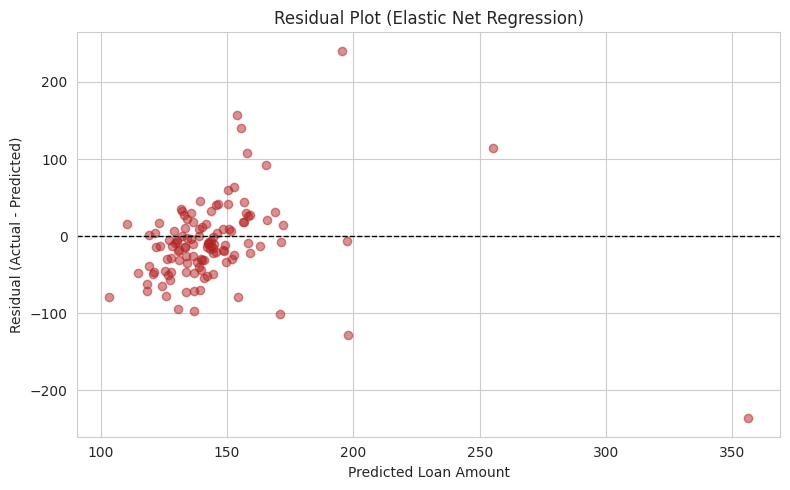

In [ ]:
# Residual plot 
residuals = y_test.values - best_pred

plt.figure()
plt.scatter(best_pred, residuals, alpha=0.5, color="firebrick")
plt.axhline(0, color="black", linestyle="--", lw=1)
plt.xlabel("Predicted Loan Amount")
plt.ylabel("Residual (Actual - Predicted)")
plt.title(f"Residual Plot ({best_name})")
plt.tight_layout()
plt.show()


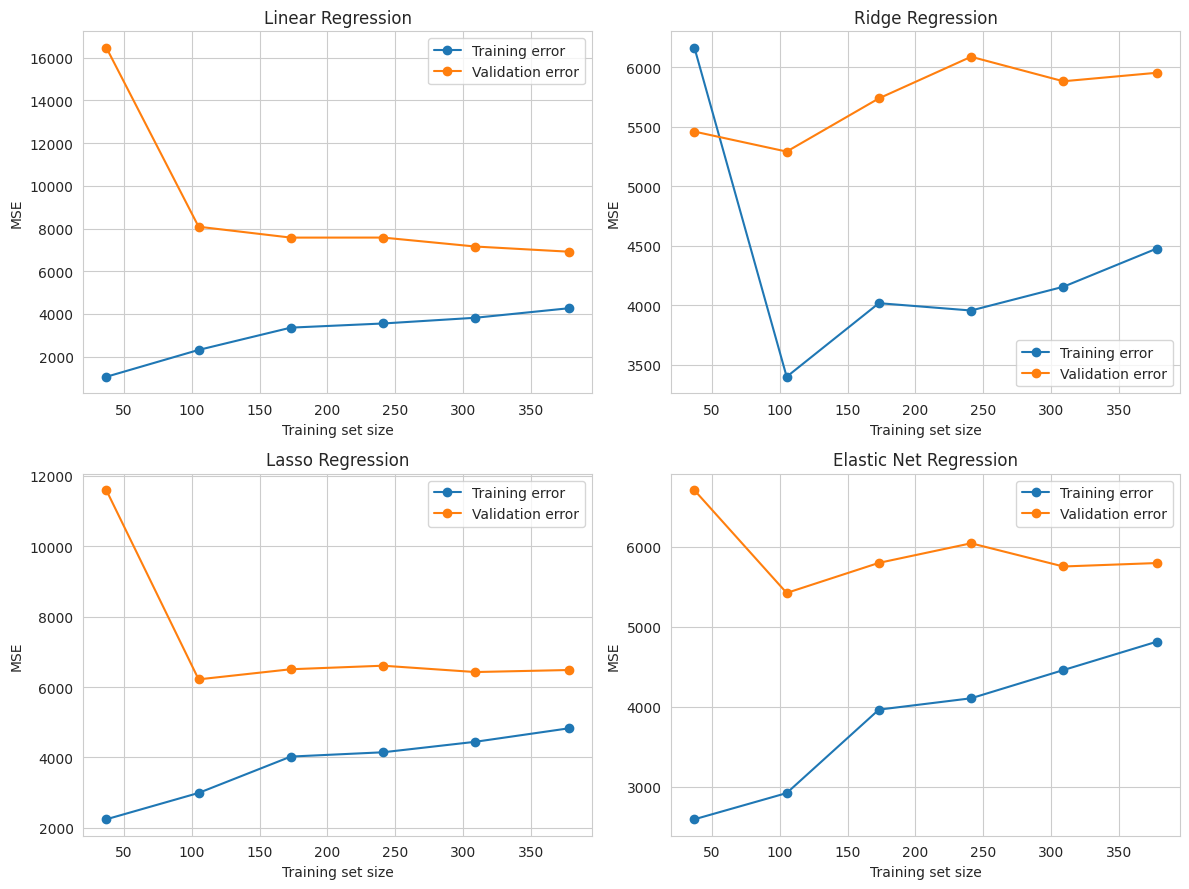

In [ ]:
#  Training error vs validation error plot (learning curves)
models_for_lc = {
    "Linear Regression": make_pipeline(LinearRegression()),
    "Ridge Regression": ridge_model,
    "Lasso Regression": lasso_model,
    "Elastic Net Regression": enet_model,
}

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, (name, est) in zip(axes.ravel(), models_for_lc.items()):
    train_sizes, train_scores, val_scores = learning_curve(
        est, X_train, y_train, cv=5,
        scoring="neg_mean_squared_error",
        train_sizes=np.linspace(0.1, 1.0, 6), n_jobs=-1,
    )
    train_err = -train_scores.mean(axis=1)
    val_err = -val_scores.mean(axis=1)
    ax.plot(train_sizes, train_err, "o-", label="Training error")
    ax.plot(train_sizes, val_err, "o-", label="Validation error")
    ax.set_title(name)
    ax.set_xlabel("Training set size")
    ax.set_ylabel("MSE")
    ax.legend()
plt.tight_layout()
plt.show()


In [32]:
# Feature names after preprocessing (numeric + one-hot expanded categorical)
feature_names = (
    numerical_cols
    + list(preprocessor.named_transformers_["cat"]["onehot"].get_feature_names_out(categorical_cols))
)

coef_table = pd.DataFrame({
    "Feature": feature_names,
    "Linear": lin_model.named_steps["regressor"].coef_,
    "Ridge": ridge_model.named_steps["regressor"].coef_,
    "Lasso": lasso_model.named_steps["regressor"].coef_,
    "Elastic Net": enet_model.named_steps["regressor"].coef_,
})
coef_table


,Feature,Linear,Ridge,Lasso,Elastic Net
0,ApplicantIncome,53.747433,44.500377,45.096484,35.671695
1,CoapplicantIncome,22.378053,17.580750,11.914155,13.232641
2,Loan_Amount_Term,8.125923,5.806237,0.000000,3.628580
3,Credit_History,1.472321,1.124281,0.000000,0.569871
4,Gender_Female,-0.187099,-1.565257,-0.000000,-1.222597
5,Gender_Male,0.187099,1.565257,0.000000,1.222621
6,Married_No,-9.753131,-7.121065,-0.000000,-5.042147
7,Married_Yes,9.753131,7.121065,0.000000,5.042124
8,Dependents_0,-9.272126,-6.969971,-0.000000,-4.996061
9,Dependents_1,4.130605,2.652282,0.000000,1.103251


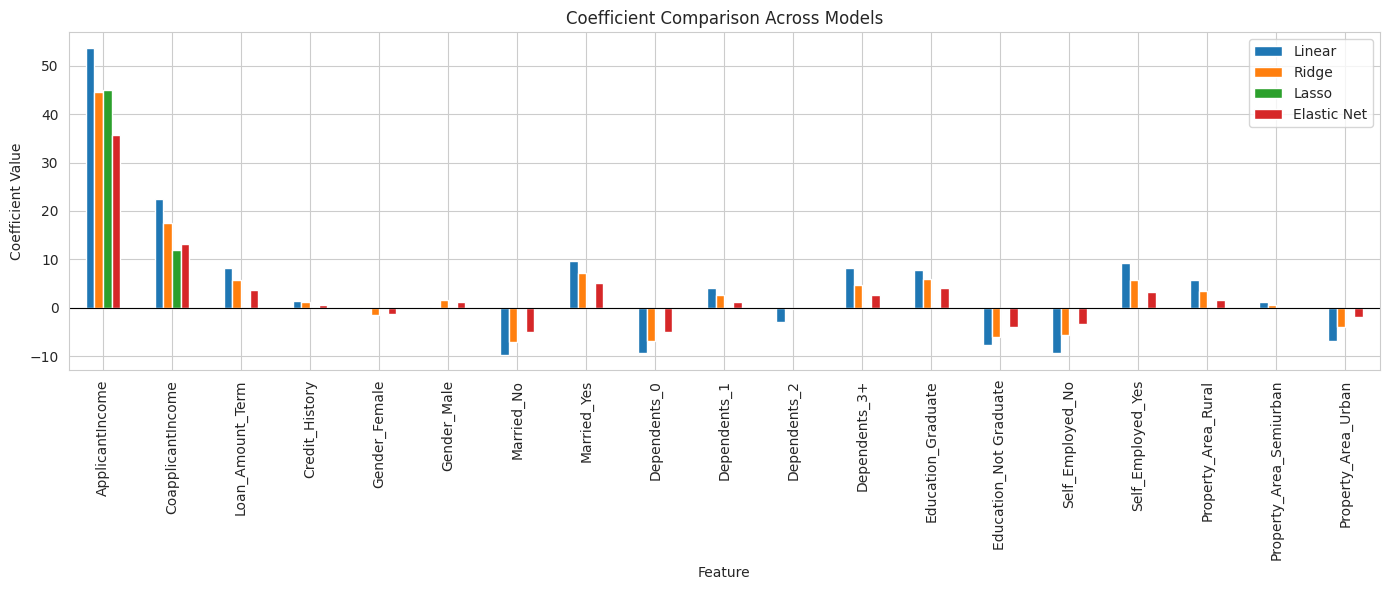

In [ ]:
# Coefficient comparison bar plot 
coef_plot_df = coef_table.set_index("Feature")
coef_plot_df.plot(kind="bar", figsize=(14, 6))
plt.title("Coefficient Comparison Across Models")
plt.ylabel("Coefficient Value")
plt.axhline(0, color="black", lw=0.8)
plt.tight_layout()
plt.show()


In [34]:
overfit_table = pd.DataFrame([
    {"Model": "Linear Regression", "Train_R2": lin_metrics["Train_R2"], "Test_R2": lin_metrics["R2"],
     "Gap (Train - Test)": lin_metrics["Train_R2"] - lin_metrics["R2"]},
    {"Model": "Ridge Regression", "Train_R2": ridge_metrics["Train_R2"], "Test_R2": ridge_metrics["R2"],
     "Gap (Train - Test)": ridge_metrics["Train_R2"] - ridge_metrics["R2"]},
    {"Model": "Lasso Regression", "Train_R2": lasso_metrics["Train_R2"], "Test_R2": lasso_metrics["R2"],
     "Gap (Train - Test)": lasso_metrics["Train_R2"] - lasso_metrics["R2"]},
    {"Model": "Elastic Net Regression", "Train_R2": enet_metrics["Train_R2"], "Test_R2": enet_metrics["R2"],
     "Gap (Train - Test)": enet_metrics["Train_R2"] - enet_metrics["R2"]},
])
overfit_table


,Model,Train_R2,Test_R2,Gap (Train - Test)
0,Linear Regression,0.455789,0.090389,0.365401
1,Ridge Regression,0.438671,0.157750,0.280921
2,Lasso Regression,0.389539,0.137025,0.252514
3,Elastic Net Regression,0.392590,0.171699,0.220892
